# 03 — density ablation: reconstruction across MAE checkpoints

Side-by-side reconstruction of the **atomblob / density / merged** ViT-MAE pretraining variants on a single, atom-type-diverse CrossDocked val sample, all under one **shared block mask** — so column-to-column differences are architecture/training effects, not mask noise.

Edit `MODEL_IDXS` to pick which checkpoints to compare (cell 2 prints the indexed list). The sample is auto-selected for maximal ligand atom-type diversity (override with `SAMPLE_IDX`). **Models are columns** throughout.

| `input_mode` | channels | density idx |
|---|---|---|
| `atomblob` | 11 = lig C/O/N/S/F/Cl/P (0:7) + poc C/O/N/S (7:11) | — |
| `atomblob_density` | 12 = 11 atoms + density | 11 |
| `atomblob_merged` | 7 = merged C/O/N/S + lig F/Cl/P | — |
| `atomblob_merged_density` | 8 = 7 merged atoms + density | 7 |

Plots: **1** density recon · **2** coordinate (total-atom) recon · **3** per-channel lig/poc (11) · **4** per-channel merged (7) · **5** masked-voxel histograms.


In [1]:
# ── imports + scan available MAE checkpoints ────────────────────────────────
import gemmi                       # import before torch (avoids silent _load_grid failures)
import sys, glob
from pathlib import Path
VOX_ROOT = '/home/shpark/prj-denovo/VoxBind'
if VOX_ROOT not in sys.path:
    sys.path.insert(0, VOX_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from voxbind.models.density_vit import DensityViTMAE
from voxbind.dataset.crossdocked_xray import DatasetCrossDockedXray
from voxbind.voxelizer import Voxelizer
from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED

DEVICE = 7                                                # GPU index to run on
device = torch.device(f'cuda:{DEVICE}' if torch.cuda.is_available() else 'cpu')
torch.set_grad_enabled(False)
ELEMS = list(ELEMENTS_HASH_CROSSDOCKED.keys())[:7]        # C O N S F Cl P (ligand channels)

DATA_DIR  = f'{VOX_ROOT}/voxbind/dataset/data'
CROPS_DIR = f'{DATA_DIR}/xray_crops_aligned'
EXPS_DIR  = f'{VOX_ROOT}/voxbind/exps'

import re
def max_snapshot_epoch(exp_dir):
    eps = [int(m.group(1)) for f in Path(exp_dir).glob('checkpoint_*.pth.tar')
           for m in [re.search(r'checkpoint_e?(\d+)\.pth\.tar', f.name)] if m]
    return max(eps) if eps else -1

def latest_ckpt(exp_dir):
    rolling = Path(exp_dir) / 'checkpoint.pth.tar'
    if rolling.exists():
        return str(rolling)
    numbered = sorted(Path(exp_dir).glob('checkpoint_e*.pth.tar')) or sorted(Path(exp_dir).glob('checkpoint_*.pth.tar'))
    return str(numbered[-1]) if numbered else None

# Keep only ViT-MAE atomblob/density runs: input_mode set, pretext 'mae', a checkpoint present.
CANDS = []
for cfgp in sorted(glob.glob(f'{EXPS_DIR}/*/cfg.yaml')):
    exp = Path(cfgp).parent
    try:
        c = OmegaConf.load(cfgp)
        im = c.get('input_mode')
        ps = c.mae.get('pretext_style', 'mae') if 'mae' in c else None
        ck = latest_ckpt(exp)
        if im is None or ps != 'mae' or ck is None:
            continue
        CANDS.append({'exp': exp.name, 'ckpt': ck, 'input_mode': str(im),
                      'n_in': int(c.model.n_in_channels), 'mature': max_snapshot_epoch(exp)})
    except Exception:
        continue

print(f'{len(CANDS)} MAE checkpoints found  (mature = highest numbered-snapshot epoch):\n')
for i, m in enumerate(CANDS):
    print(f'  [{i:2d}] {m["exp"]:62s} {m["input_mode"]:24s} n_in={m["n_in"]:2d}  mature~ep{m["mature"]}')
print('\ndevice:', device)

10 MAE checkpoints found  (mature = highest numbered-snapshot epoch):

  [ 0] 260526_atomblob_density_vit_mae_40m_pretrain                   atomblob_density         n_in=12  mature~ep99
  [ 1] 260526_atomblob_vit_mae_40m_pretrain                           atomblob                 n_in=11  mature~ep99
  [ 2] 260528_atomblob_vit_mae_40m_weighted_pretrain                  atomblob                 n_in=11  mature~ep99
  [ 3] 260529_atomblob_density_vit_mae_40m_weighted_pretrain          atomblob_density         n_in=12  mature~ep40
  [ 4] 260530_atomblob_merged_density_vit_mae_40m_weighted_pretrain   atomblob_merged_density  n_in= 8  mature~ep99
  [ 5] 260530_atomblob_merged_density_vit_mae_40m_weighted_v2_pretrain atomblob_merged_density  n_in= 8  mature~ep99
  [ 6] 260530_atomblob_merged_density_vit_mae_40m_weighted_v3_pretrain atomblob_merged_density  n_in= 8  mature~ep99
  [ 7] 260601_atomblob_merged_density_vit_mae_40m_weighted_v4_pretrain atomblob_merged_density  n_in= 8  mature~ep9

In [27]:
# ── SELECT models (edit MODEL_IDXS using the indices printed above) ─────────
# Default: the most-trained checkpoint of each distinct input_mode (one column each).
_rep = {}
for i, m in enumerate(CANDS):
    j = _rep.get(m['input_mode'])
    if j is None or (m['mature'], i) >= (CANDS[j]['mature'], j):   # prefer mature, then latest
        _rep[m['input_mode']] = i
MODEL_IDXS = sorted(_rep.values())
# e.g.  MODEL_IDXS = [2, 7, 8]   to hand-pick rows (in-flight runs included).
MODEL_IDXS = [0, 1, 3, 4, 5, 7, 8]

SAMPLE_IDX   = None      # None -> auto-pick the most atom-type-diverse val sample
SLICE_AXIS   = 'z'       # 'x' | 'y' | 'z'z
SLICE_OFFSET = 0
SEED_MASK    = 0         # shared mask seed (same as the 260528/260601 notebooks)
BLOCK_SIZE   = 8
MASK_RATIO   = 0.60
RESOLUTION   = 0.25
GRID_DIM     = 64
POS_THRESH   = 0.05

DENS_IDX = {'density': 0, 'atomblob': None, 'atomblob_density': 11,
            'atomblob_merged': None, 'atomblob_merged_density': 7}

def build_model(ckpt_path):
    ck = torch.load(ckpt_path, map_location='cpu', weights_only=False)   # cpu load -> small GPU footprint
    cfg = ck['cfg']
    # Reconstruct the exact head architecture from cfg (mirrors train_density_vit_mae.py::main),
    # so single-head, dual-head, and gradmag checkpoints all load drop-in. Defaults below match
    # the constructor defaults, so pre-knob checkpoints (260526 etc.) are unaffected.
    #   dual_head        : split the recon head into atoms-branch + 1-ch density-branch
    #   head_hidden_dim  : MLP-head hidden width; 0 -> c_half (= n_channels//2)
    #   head_depth       : total Conv3d layers per recon head (>=1)
    #   n_recon_channels : recon/loss-target width; < n_in when gradmag is input-only.
    # NB: dual-head output channel order is unchanged ([atoms..., density]), so dens_idx and
    #     every per-channel helper below keep working — only the head's internals differ.
    n_in       = int(cfg.model.n_in_channels)
    dual_head  = bool(cfg.model.get('dual_head', False))
    head_hid   = int(cfg.model.get('head_hidden_dim', 0))   # 0 -> c_half
    head_depth = int(cfg.model.get('head_depth', 2))
    pretext    = str(cfg.mae.get('pretext_style', 'mae')) if 'mae' in cfg else 'mae'
    with_gradmag  = bool(cfg.get('with_gradmag', False))
    gradmag_recon = bool(cfg.mae.get('gradmag_reconstruct', True)) if 'mae' in cfg else True
    n_recon = n_in - (0 if gradmag_recon else (1 if with_gradmag else 0))   # gradmag may be input-only
    m = DensityViTMAE(
        grid_dim=int(cfg.vox.grid_dim), patch_size=int(cfg.model.patch_size),
        n_in_channels=n_in, n_recon_channels=n_recon, n_channels=int(cfg.model.n_channels),
        dim=int(cfg.model.dim), depth=int(cfg.model.depth), n_heads=int(cfg.model.heads),
        mlp_ratio=int(cfg.model.mlp_ratio), dropout=float(cfg.model.dropout),
        n_struct_channels=int(cfg.model.n_struct_channels),
        pretext_style=pretext, dual_head=dual_head,
        head_hidden_dim=head_hid, head_depth=head_depth,
    ).to(device).eval()
    sd = ck.get('state_dict_ema', ck.get('state_dict'))
    sd = {k.replace('module.', '').replace('_orig_mod.', ''): v for k, v in sd.items()}
    miss, unexp = m.load_state_dict(sd, strict=False)
    return m, int(ck.get('epoch', -1)), int(ck.get('global_step', -1)), miss, unexp, dual_head

MODELS = []
for idx in MODEL_IDXS:
    c = CANDS[idx]
    net, ep, step, miss, unexp, dual = build_model(c['ckpt'])
    im = c['input_mode']
    short = c['exp'].replace('_vit_mae_40m', '').replace('_pretrain', '')
    MODELS.append({'net': net, 'input_mode': im, 'epoch': ep, 'step': step, 'exp': c['exp'],
                   'dual_head': dual,
                   'label': f'{short}\n(ep{ep}, {im})', 'dens_idx': DENS_IDX[im]})
    tag = '  [dual-head]' if dual else ''
    print(f"[{idx:2d}] {c['exp']:60s} {im:24s}  trained_epoch={ep:<4d} (global_step={step})  miss={len(miss)} unexp={len(unexp)}{tag}")
print(f'\nComparing {len(MODELS)} model(s) as columns.')

[ 0] 260526_atomblob_density_vit_mae_40m_pretrain                 atomblob_density          trained_epoch=99   (global_step=98000)  miss=0 unexp=0
[ 1] 260526_atomblob_vit_mae_40m_pretrain                         atomblob                  trained_epoch=99   (global_step=98000)  miss=0 unexp=0
[ 3] 260529_atomblob_density_vit_mae_40m_weighted_pretrain        atomblob_density          trained_epoch=47   (global_step=47088)  miss=0 unexp=0
[ 4] 260530_atomblob_merged_density_vit_mae_40m_weighted_pretrain atomblob_merged_density   trained_epoch=99   (global_step=81700)  miss=0 unexp=0
[ 5] 260530_atomblob_merged_density_vit_mae_40m_weighted_v2_pretrain atomblob_merged_density   trained_epoch=99   (global_step=81700)  miss=0 unexp=0
[ 7] 260601_atomblob_merged_density_vit_mae_40m_weighted_v4_pretrain atomblob_merged_density   trained_epoch=99   (global_step=81700)  miss=0 unexp=0
[ 8] 260602_atomblob_merged_density_vit_mae_40m_weighted_v4_dualhead_pretrain atomblob_merged_density   trained_

In [ ]:
# ── Characteristics: what differs across the loaded columns (runs = rows) ───
# One row per selected run (same idx as the cell above); columns are the knobs
# that vary across the atomblob / density / merged · single- vs dual-head ·
# weighting variants. Structural facts read from the loaded net; training knobs
# from each run's cfg.yaml.
import pandas as pd

_INPUTS = {
    'density':                 'density',
    'atomblob':                'atoms',
    'atomblob_density':        'atoms + density',
    'atomblob_merged':         'merged atoms',
    'atomblob_merged_density': 'merged atoms + density',
}

def _char_row(M):
    cfg = OmegaConf.load(f"{EXPS_DIR}/{M['exp']}/cfg.yaml")
    mae = cfg.get('mae', {})
    net = M['net']
    idx = next(i for i, cc in enumerate(CANDS) if cc['exp'] == M['exp'])
    n_ch = int(cfg.model.n_channels)
    hh   = int(cfg.model.get('head_hidden_dim', 0)) or (n_ch // 2)     # 0 -> c_half
    hd   = int(cfg.model.get('head_depth', 2))
    posw = float(mae.get('atom_pos_weight', 1.0))
    chw  = str(mae.get('channel_weighting', 'uniform'))
    return {
        'idx':        idx,
        'run':        M['exp'].replace('_vit_mae_40m', '').replace('_pretrain', ''),
        'inputs':     _INPUTS.get(M['input_mode'], M['input_mode']),   # which modalities feed the encoder
        'n_in':       int(net.n_in_channels),                          # input channel count
        'epoch':      M['epoch'],                                      # trained epoch (EMA ckpt)
        'dual_MLP':   '✓' if M['dual_head'] else '—',                  # split atoms/density recon heads
        'recon_head': f'{hd}L×{hh}',                                   # recon head: depth × hidden width
        'ch_weight':  '—' if chw == 'uniform' else chw.replace('inv_sqrt_freq', 'inv√freq'),
        'pos_weight': '—' if posw <= 1.0 else f'{posw:g}×',            # atom-on voxel error up-weight
        'dens_src':   str(mae.get('density_source', '—')),             # xray vs synthetic density
        'mask':       str(mae.get('mask_strategy', 'uniform')),        # block-mask sampling strategy
        'struct_ch':  '—' if int(net.n_struct_channels) == 0 else str(int(net.n_struct_channels)),
    }

char_df = pd.DataFrame([_char_row(M) for M in MODELS]).set_index('idx')
char_df

In [28]:
# ── pick sample, voxelize, build shared mask, forward every model ───────────
dset = DatasetCrossDockedXray(
    data_dir=DATA_DIR, crops_dir=CROPS_DIR, split='val', aug=False, small=False,
    ligand_radius=0.5, pocket_radius=-1, use_xray=True, normalize=True,
    subset_xray_only=True, subset_n=78428, subset_val_n=100,
)

if SAMPLE_IDX is None:
    best, best_key = 0, (-1, -1)
    for i in range(len(dset)):
        ch = dset[i]['ligand']['atoms_channel'].long()
        u = set(ch[ch < 7].tolist())                 # drop padding (999) and H (7)
        key = (len(u), len(u & {4, 5, 6}))           # diversity, then rare-element (F/Cl/P) count
        if key > best_key:
            best_key, best = key, i
    SAMPLE_IDX = best
    print(f'auto-picked SAMPLE_IDX={SAMPLE_IDX}  (atom types={best_key[0]}, rare F/Cl/P={best_key[1]})')

sample = dset[SAMPLE_IDX]
lig_elems = sorted({ELEMS[i] for i in sample['ligand']['atoms_channel'].long().tolist() if i < 7})
print(f"sample {SAMPLE_IDX}: {sample['ligand']['id']}")
print(f"  ligand elements present: {lig_elems}")

voxelizer = Voxelizer(grid_dim=GRID_DIM, resolution=RESOLUTION, cubes_around=8, device=device)
lig = {k: sample['ligand'][k].unsqueeze(0).to(device) for k in ('coords', 'radius', 'atoms_channel')}
poc = {k: sample['pocket'][k].unsqueeze(0).to(device) for k in ('coords', 'radius', 'atoms_channel')}
v_lig = voxelizer(lig, num_channels=7)                                # (1, 7, G^3)
v_poc = voxelizer(poc, num_channels=4)                                # (1, 4, G^3)
d_xray = sample['xray_density'].unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, G^3)
v_merged = v_lig.clone(); v_merged[:, :4] = v_merged[:, :4] + v_poc   # (1, 7, G^3)

# One block mask, broadcast across every channel of every model.
g = torch.Generator(device=device).manual_seed(SEED_MASK)
blocks = torch.rand(1, 1, *([GRID_DIM // BLOCK_SIZE] * 3), device=device, generator=g) < MASK_RATIO
mask = blocks.repeat_interleave(BLOCK_SIZE, 2).repeat_interleave(BLOCK_SIZE, 3).repeat_interleave(BLOCK_SIZE, 4)
mask_3d = mask[0, 0]
keep = (~mask_3d.bool()).float()
print(f'mask fraction {mask.float().mean().item():.3f} (target {MASK_RATIO}); shared across all models')

def build_input(im):
    if im == 'density':                 return d_xray
    if im == 'atomblob':                return torch.cat([v_lig, v_poc], 1)
    if im == 'atomblob_density':        return torch.cat([v_lig, v_poc, d_xray], 1)
    if im == 'atomblob_merged':         return v_merged
    if im == 'atomblob_merged_density': return torch.cat([v_merged, d_xray], 1)

for M in MODELS:
    M['out'] = M['net'](build_input(M['input_mode']) * keep)[0]        # (1, C, G^3)
    print(f"  {M['input_mode']:24s} forward -> {tuple(M['out'].shape)}")

# ── ground-truth views + per-model view helpers ─────────────────────────────
gt_dens   = d_xray[0, 0]
gt_total  = v_merged[0].sum(0)                                         # total atom occupancy
gt_ligpoc = torch.cat([v_lig, v_poc], 1)[0]                           # (11, G^3)
gt_merged = v_merged[0]                                               # (7, G^3)
LIGPOC_NAMES = [f'lig {e}' for e in ELEMS] + [f'poc {e}' for e in ELEMS[:4]]
MERGED_NAMES = [f'{e}\n(lig+poc)' if i < 4 else f'{e}\n(lig)' for i, e in enumerate(ELEMS)]

def atoms_ligpoc(M):     # (11, G^3) lig/poc-resolved atom prediction, or None
    o, im = M['out'][0], M['input_mode']
    if im in ('atomblob', 'atomblob_density'):                  return o[:11]
    if im in ('atomblob_merged', 'atomblob_merged_density'):
        a = o[:7]; return torch.cat([a, a[:4]], 0)              # poc C/O/N/S reuse merged C/O/N/S
    return None

def atoms_merged(M):     # (7, G^3) merged atom prediction, or None
    o, im = M['out'][0], M['input_mode']
    if im in ('atomblob_merged', 'atomblob_merged_density'):    return o[:7]
    if im in ('atomblob', 'atomblob_density'):
        a = o[:11].clone(); a[:4] = a[:4] + a[7:11]; return a[:7]
    return None

def atoms_total(M):      # (G^3) total atom occupancy, or None
    am = atoms_merged(M); return None if am is None else am.sum(0)

def dens_pred(M):        # (G^3) density prediction, or None
    di = M['dens_idx']; return None if di is None else M['out'][0, di]

def sl(vol):
    a = vol.detach().cpu().numpy() if torch.is_tensor(vol) else vol
    i = a.shape[-1] // 2 + SLICE_OFFSET
    return {'x': a[i], 'y': a[:, i], 'z': a[:, :, i]}[SLICE_AXIS]

def proj(vol):
    # max-intensity projection along SLICE_AXIS — every atom shows up regardless
    # of depth (a single slice misses the sharp, scattered ligand atoms incl. F/Cl/P).
    a = vol.detach().cpu().numpy() if torch.is_tensor(vol) else vol
    return a.max(axis={'x': 0, 'y': 1, 'z': 2}[SLICE_AXIS])

def show(ax, img, cmap='viridis', vmin=None, vmax=None):
    ax.imshow(img.T, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks([]); ax.set_yticks([])

def blank(ax, txt='-'):
    ax.text(0.5, 0.5, txt, ha='center', va='center', color='0.6', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])

auto-picked SAMPLE_IDX=60  (atom types=6, rare F/Cl/P=2)
sample 60: FA10_HUMAN_126_476_0/2p94_L_rec_2vwl_lzh_lig_tt_docked_0.sdf
  ligand elements present: ['C', 'Cl', 'F', 'N', 'O', 'S']
mask fraction 0.580 (target 0.6); shared across all models
  atomblob_density         forward -> (1, 12, 64, 64, 64)
  atomblob                 forward -> (1, 11, 64, 64, 64)
  atomblob_density         forward -> (1, 12, 64, 64, 64)
  atomblob_merged_density  forward -> (1, 8, 64, 64, 64)
  atomblob_merged_density  forward -> (1, 8, 64, 64, 64)
  atomblob_merged_density  forward -> (1, 8, 64, 64, 64)
  atomblob_merged_density  forward -> (1, 8, 64, 64, 64)


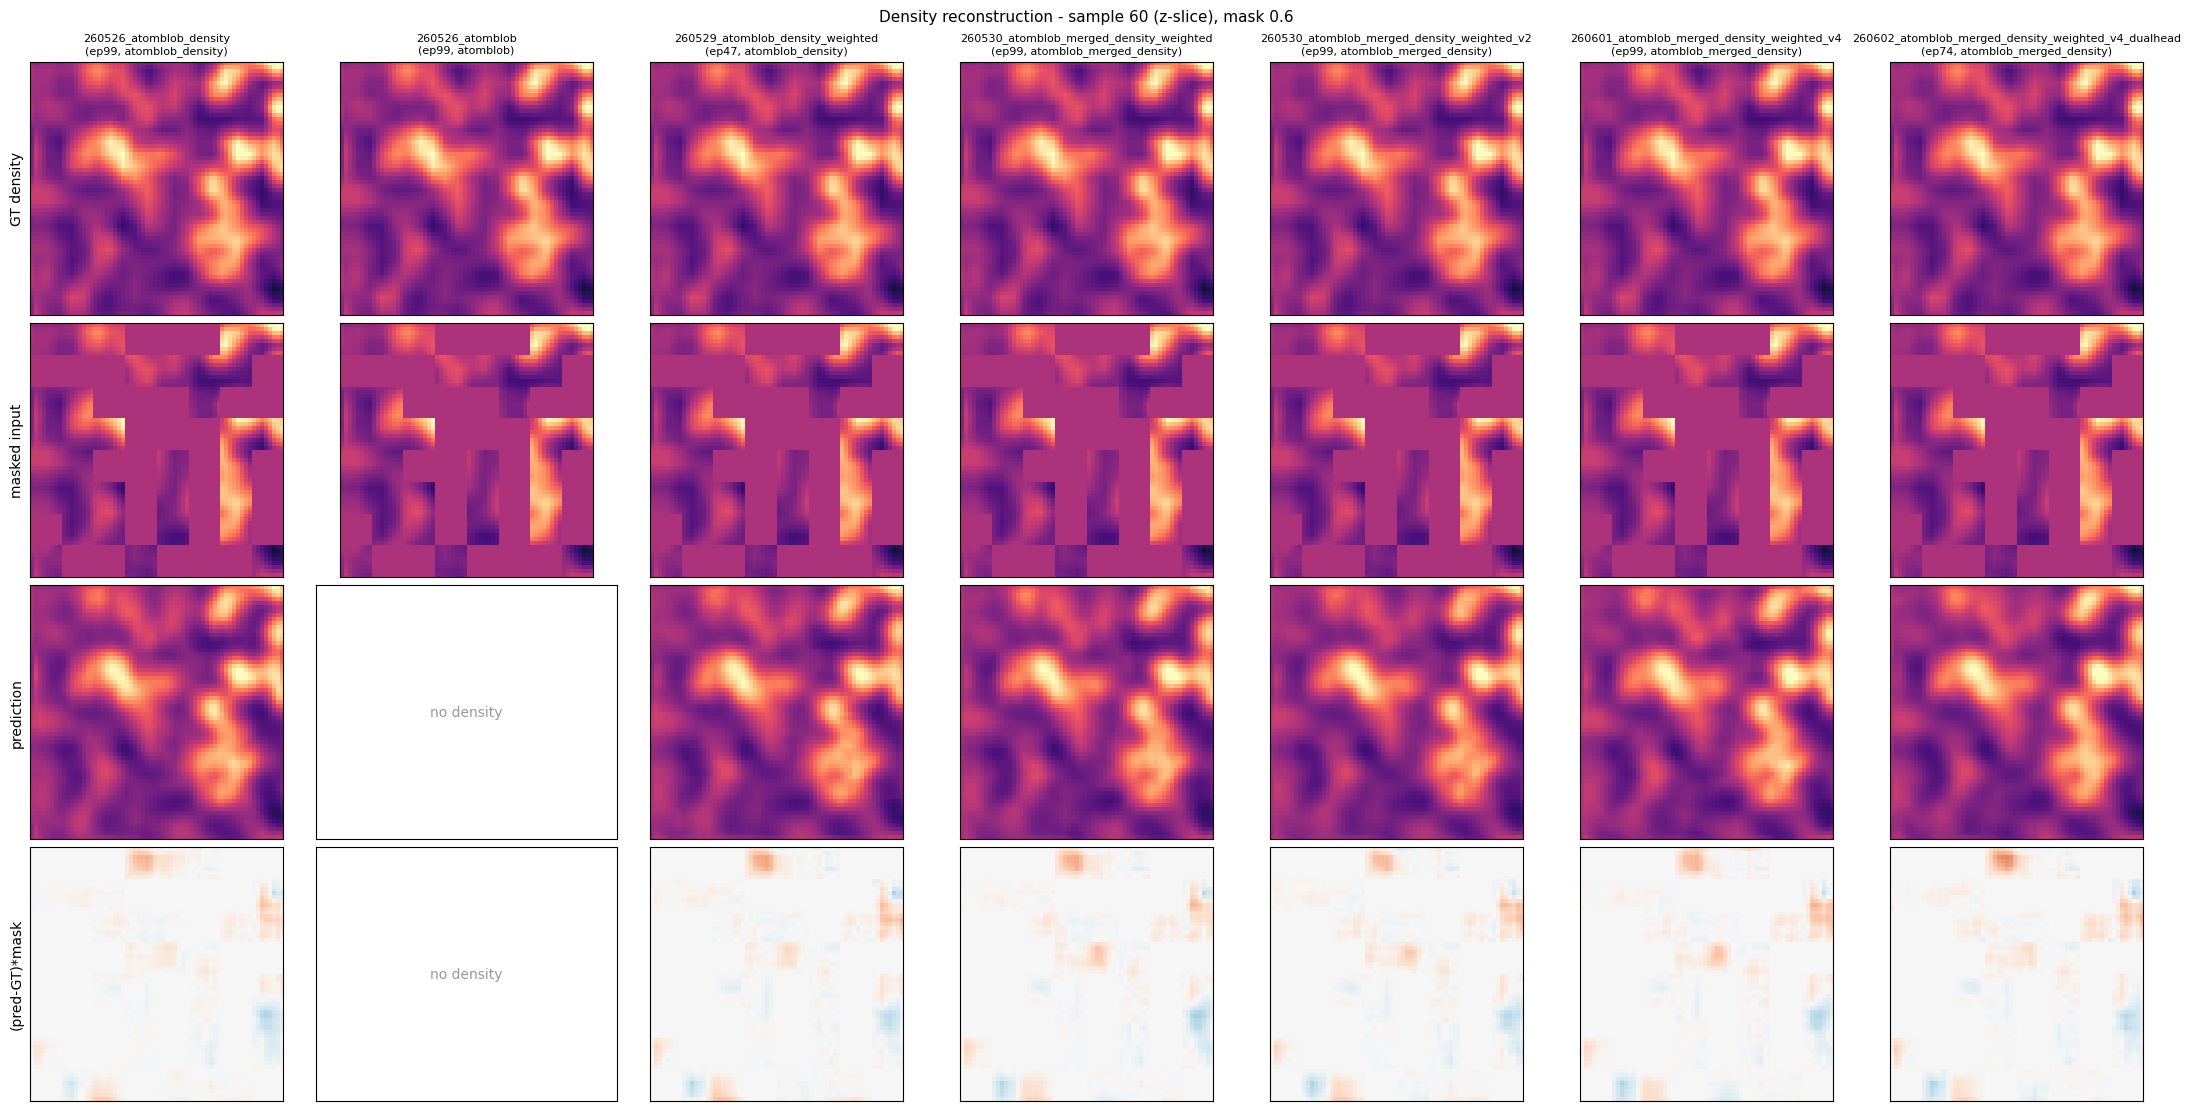

In [29]:
# ── Plot 1: density reconstruction — rows = image types, cols = models ──────
ncol = len(MODELS)
rows = ['GT density', 'masked input', 'prediction', '(pred-GT)*mask']
gt_s, in_s = sl(gt_dens), sl(gt_dens * keep)
vlo, vhi = gt_dens.min().item(), gt_dens.max().item()
eabs = max([((dens_pred(M) - gt_dens) * mask_3d).abs().max().item() for M in MODELS if dens_pred(M) is not None] + [1e-3])

fig, axes = plt.subplots(4, ncol, figsize=(3.1 * ncol, 11.0), squeeze=False, constrained_layout=True)
for j, M in enumerate(MODELS):
    axes[0, j].set_title(M['label'], fontsize=8)
    show(axes[0, j], gt_s, 'magma', vlo, vhi)
    show(axes[1, j], in_s, 'magma', vlo, vhi)
    pd = dens_pred(M)
    if pd is None:
        blank(axes[2, j], 'no density'); blank(axes[3, j], 'no density')
    else:
        show(axes[2, j], sl(pd), 'magma', vlo, vhi)
        show(axes[3, j], sl((pd - gt_dens) * mask_3d), 'RdBu_r', -eabs, eabs)
for r, t in enumerate(rows):
    axes[r, 0].set_ylabel(t, fontsize=10)
fig.suptitle(f'Density reconstruction - sample {SAMPLE_IDX} ({SLICE_AXIS}-slice), mask {MASK_RATIO}', fontsize=11)
plt.show()

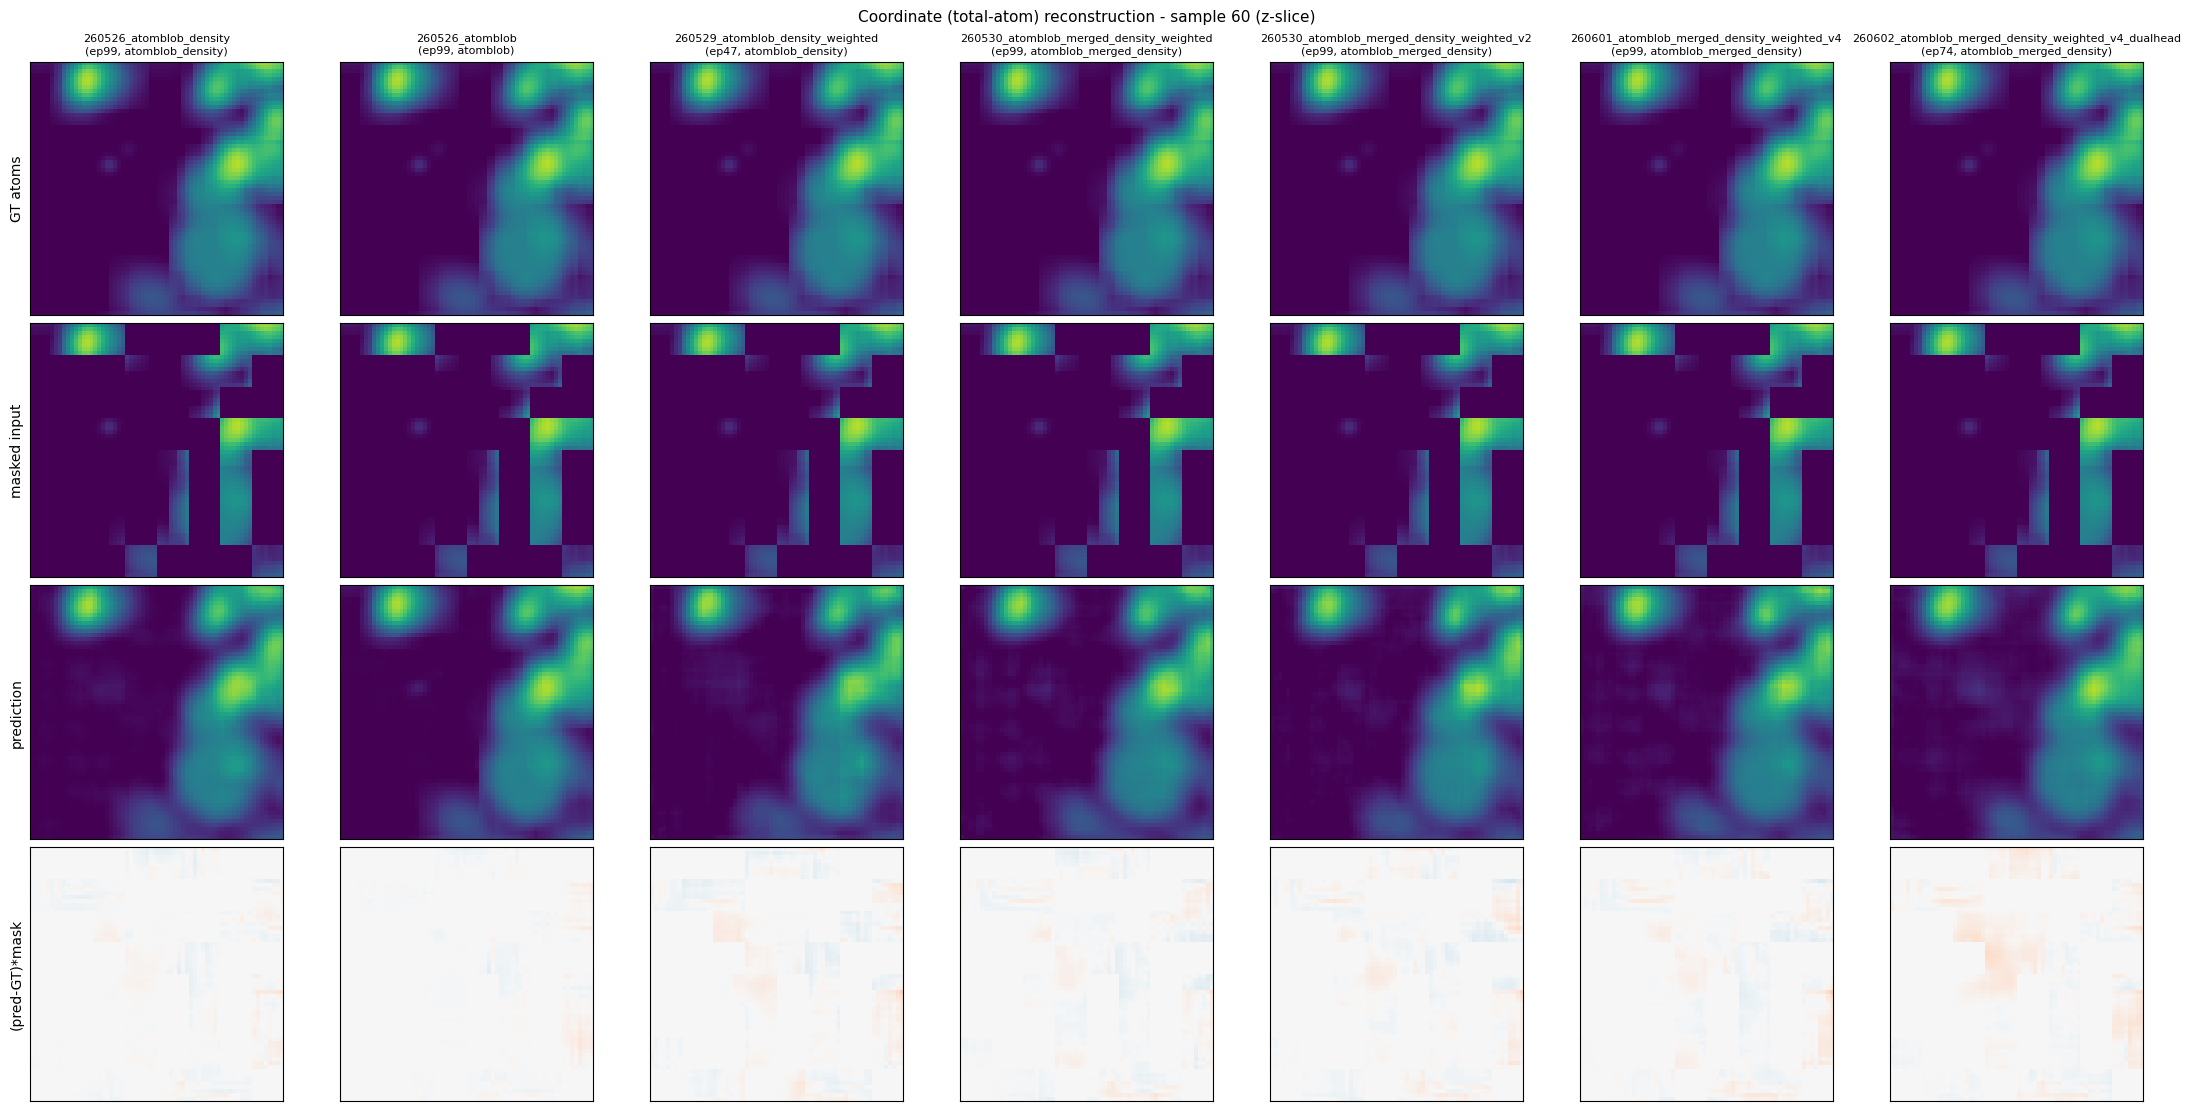

In [30]:
# ── Plot 2: coordinate (total-atom occupancy) reconstruction ────────────────
rows = ['GT atoms', 'masked input', 'prediction', '(pred-GT)*mask']
gt_s, in_s = sl(gt_total), sl(gt_total * keep)
vmax = max([gt_total.max().item(), 1e-3] + [atoms_total(M).max().item() for M in MODELS if atoms_total(M) is not None])
eabs = max([((atoms_total(M) - gt_total) * mask_3d).abs().max().item() for M in MODELS if atoms_total(M) is not None] + [1e-3])

fig, axes = plt.subplots(4, ncol, figsize=(3.1 * ncol, 11.0), squeeze=False, constrained_layout=True)
for j, M in enumerate(MODELS):
    axes[0, j].set_title(M['label'], fontsize=8)
    show(axes[0, j], gt_s, 'viridis', 0, vmax)
    show(axes[1, j], in_s, 'viridis', 0, vmax)
    at = atoms_total(M)
    if at is None:
        blank(axes[2, j], 'no atoms'); blank(axes[3, j], 'no atoms')
    else:
        show(axes[2, j], sl(at), 'viridis', 0, vmax)
        show(axes[3, j], sl((at - gt_total) * mask_3d), 'RdBu_r', -eabs, eabs)
for r, t in enumerate(rows):
    axes[r, 0].set_ylabel(t, fontsize=10)
fig.suptitle(f'Coordinate (total-atom) reconstruction - sample {SAMPLE_IDX} ({SLICE_AXIS}-slice)', fontsize=11)
plt.show()

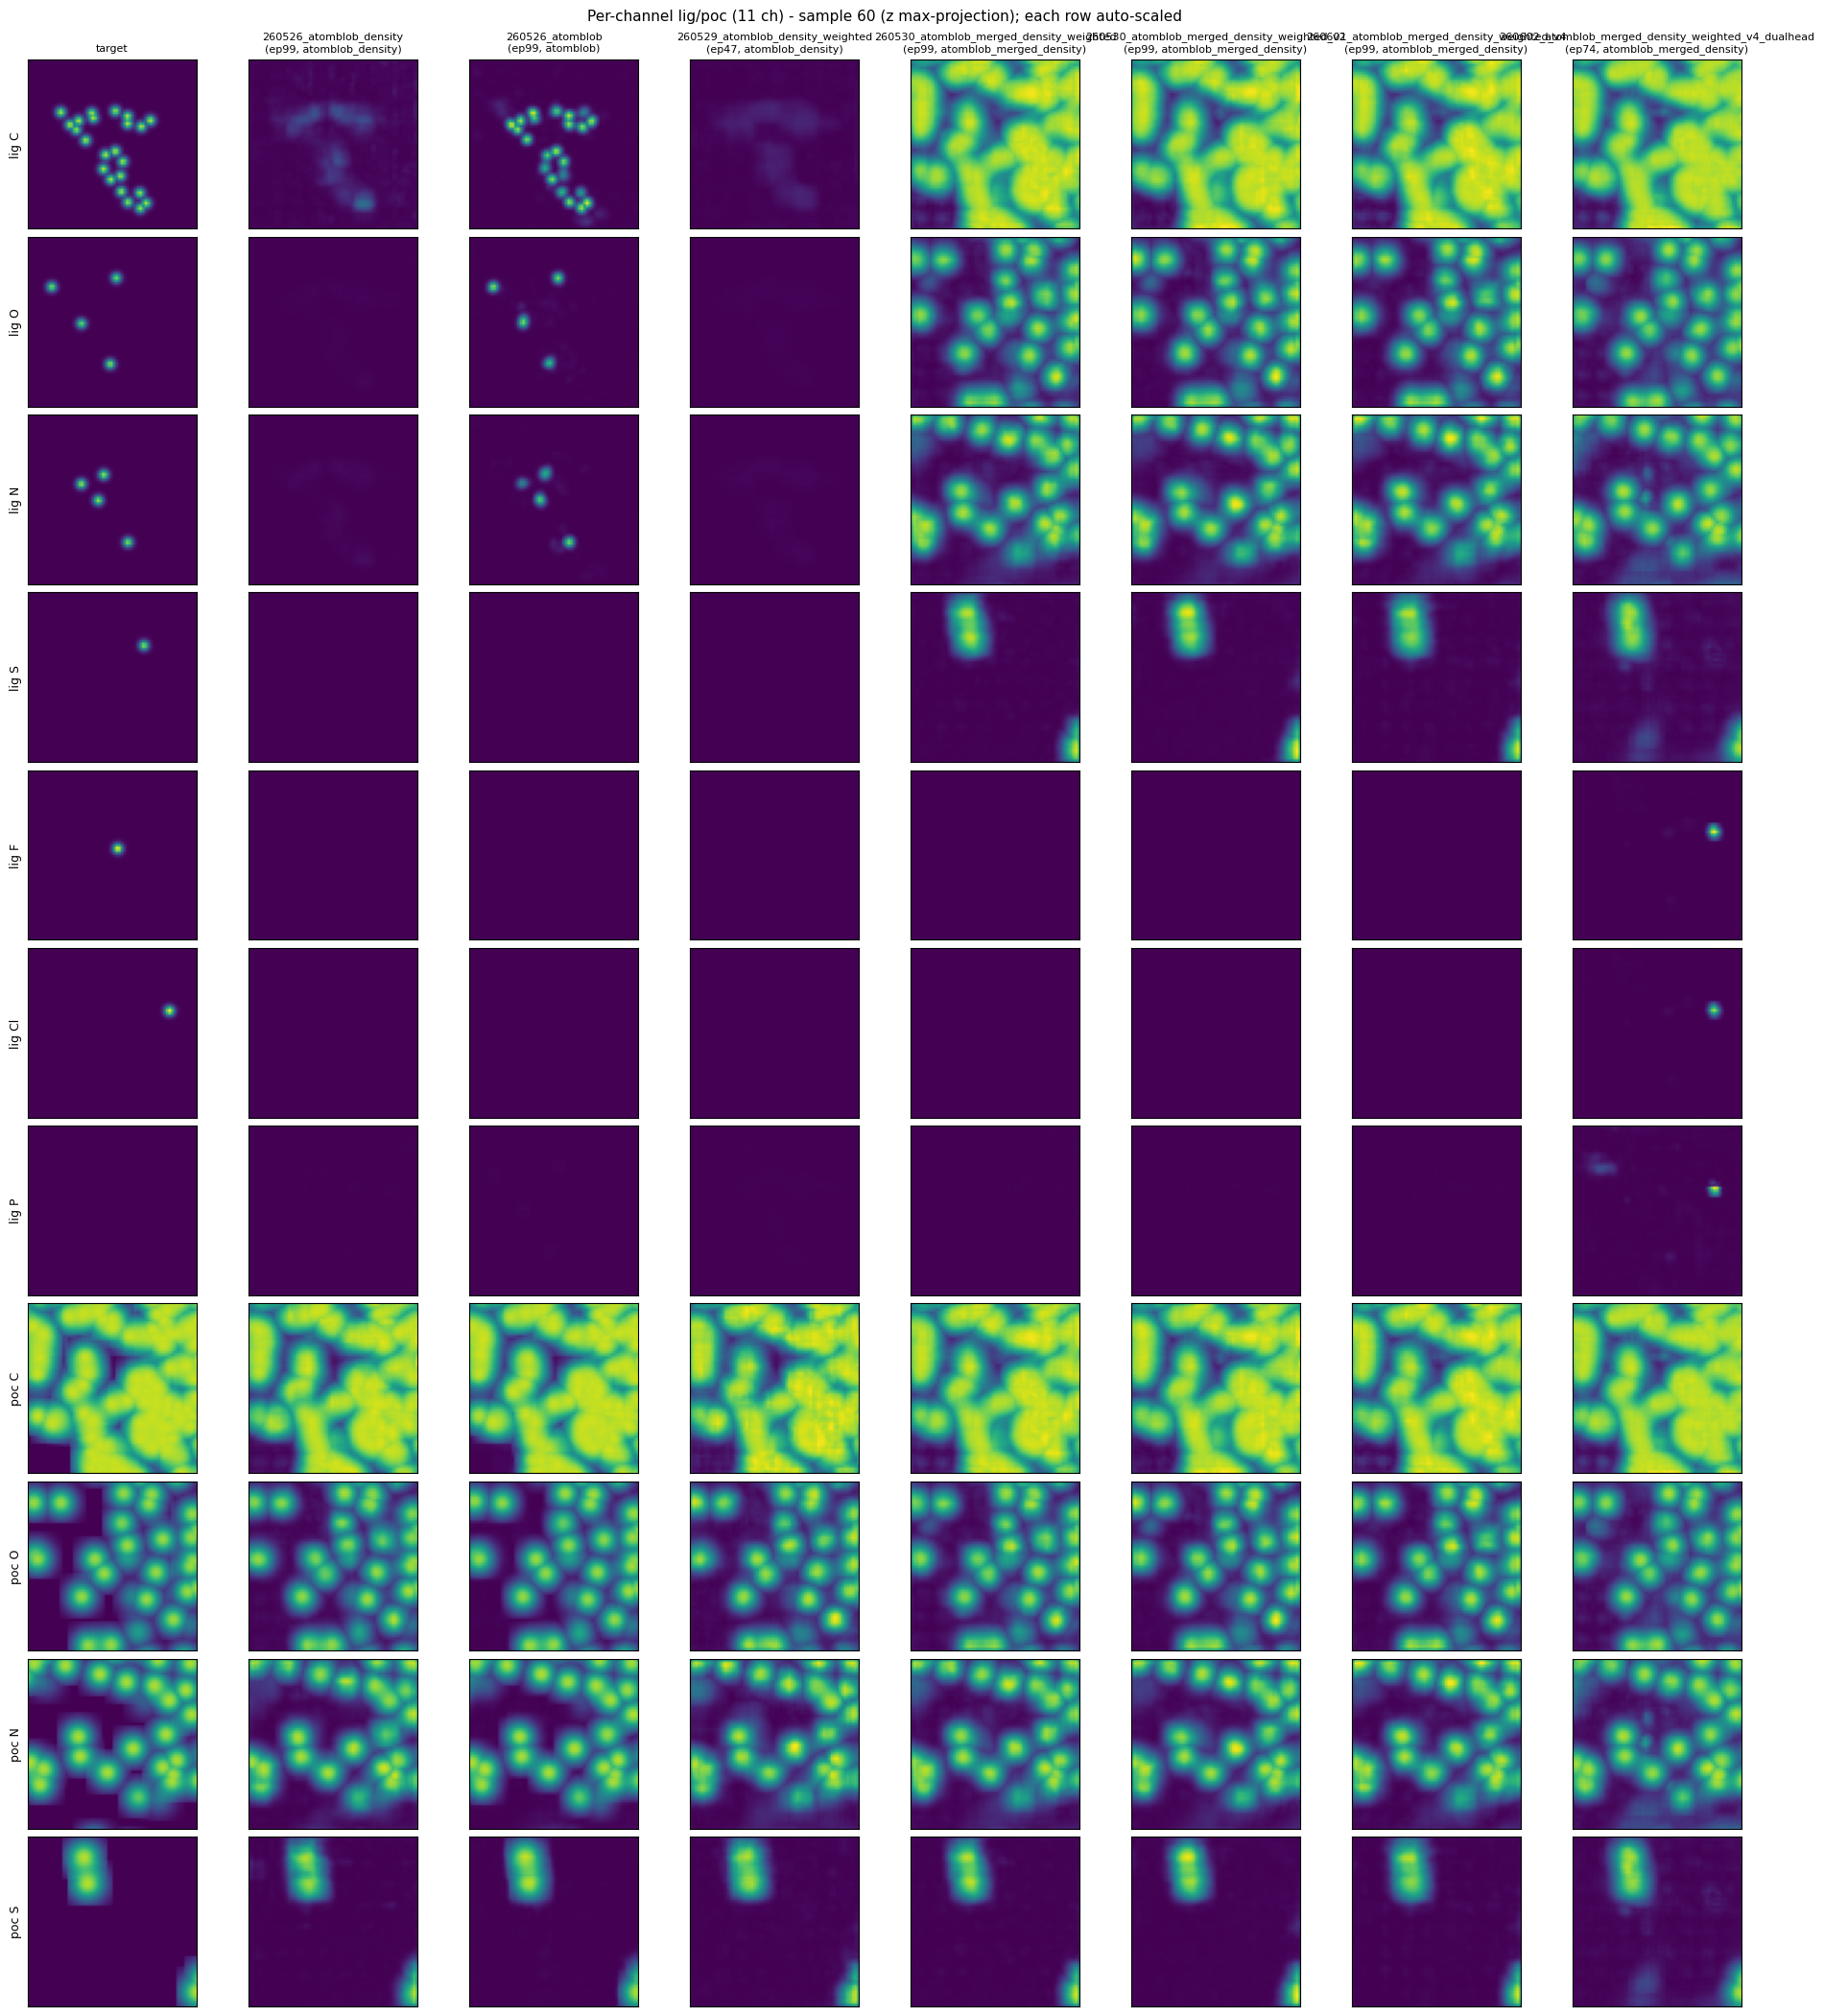

In [31]:
# ── Plot 3: per-channel lig/poc (11) — rows = atom types, cols = target+models ──
# Max-intensity projection along SLICE_AXIS so every atom (incl. rare F/Cl/P) shows.
cols = [('target', gt_ligpoc)] + [(M['label'], atoms_ligpoc(M)) for M in MODELS if atoms_ligpoc(M) is not None]
nC = len(cols)
fig, axes = plt.subplots(11, nC, figsize=(2.3 * nC, 1.9 * 11), squeeze=False, constrained_layout=True)
for r in range(11):
    vols = [c[1][r] for c in cols]
    vmax = max([v.max().item() for v in vols] + [1e-3])
    for j, v in enumerate(vols):
        show(axes[r, j], proj(v), 'viridis', 0, vmax)
    axes[r, 0].set_ylabel(LIGPOC_NAMES[r], fontsize=9)
for j, (lab, _) in enumerate(cols):
    axes[0, j].set_title(lab, fontsize=8)
fig.suptitle(f'Per-channel lig/poc (11 ch) - sample {SAMPLE_IDX} ({SLICE_AXIS} max-projection); each row auto-scaled', fontsize=11)
plt.show()

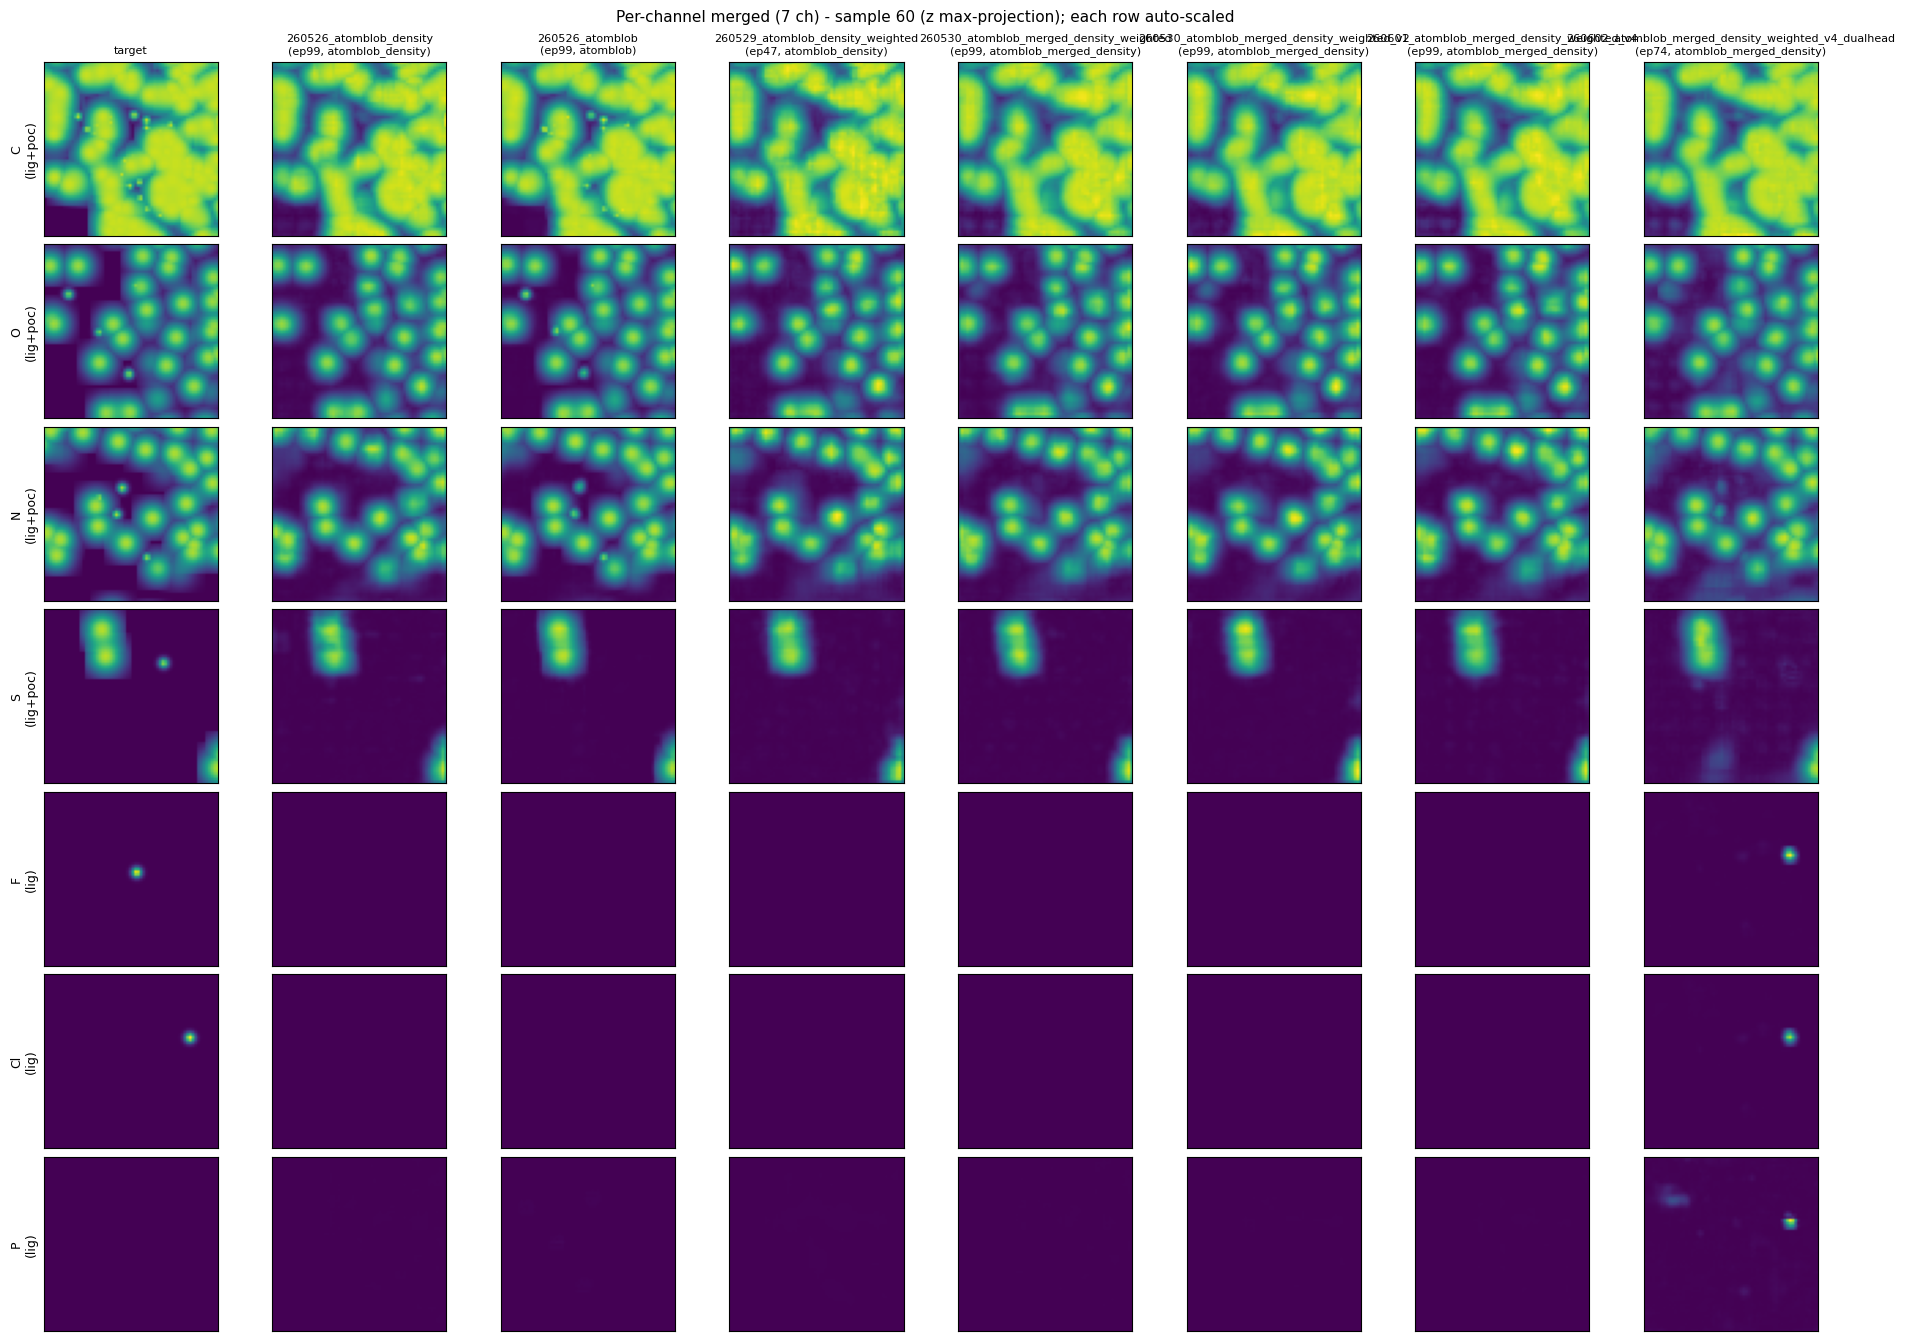

In [32]:
# ── Plot 4: per-channel merged (7) — rows = atom types, cols = target+models ──
# Max-intensity projection along SLICE_AXIS so every atom (incl. rare F/Cl/P) shows.
cols = [('target', gt_merged)] + [(M['label'], atoms_merged(M)) for M in MODELS if atoms_merged(M) is not None]
nC = len(cols)
fig, axes = plt.subplots(7, nC, figsize=(2.3 * nC, 1.9 * 7), squeeze=False, constrained_layout=True)
for r in range(7):
    vols = [c[1][r] for c in cols]
    vmax = max([v.max().item() for v in vols] + [1e-3])
    for j, v in enumerate(vols):
        show(axes[r, j], proj(v), 'viridis', 0, vmax)
    axes[r, 0].set_ylabel(MERGED_NAMES[r], fontsize=9)
for j, (lab, _) in enumerate(cols):
    axes[0, j].set_title(lab, fontsize=8)
fig.suptitle(f'Per-channel merged (7 ch) - sample {SAMPLE_IDX} ({SLICE_AXIS} max-projection); each row auto-scaled', fontsize=11)
plt.show()

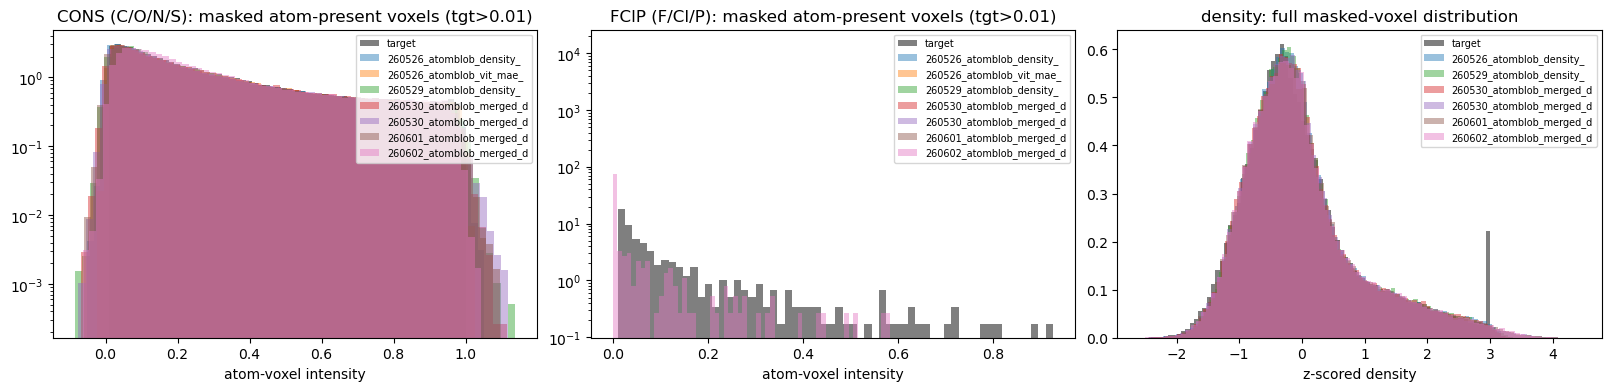

In [33]:
# ── Plot 5: histograms on masked voxels ─────────────────────────────────────
mflat = mask_3d.bool().flatten().cpu()
colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), constrained_layout=True)

for ax, (name, ch) in zip(axes[:2], [('CONS (C/O/N/S)', slice(0, 4)), ('FClP (F/Cl/P)', slice(4, 7))]):
    tgt = gt_merged[ch].flatten(1).cpu()[:, mflat].flatten().numpy()
    sel = tgt > 0.01
    if sel.any():
        ax.hist(tgt[sel], bins=60, alpha=0.5, color='k', density=True, label='target')
        for ci, M in enumerate(MODELS):
            am = atoms_merged(M)
            if am is None:
                continue
            pr = am[ch].flatten(1).cpu()[:, mflat].flatten().numpy()
            ax.hist(pr[sel], bins=60, alpha=0.45, color=colors[ci % 10], density=True, label=M['exp'][:24])
    ax.set_yscale('log'); ax.set_xlabel('atom-voxel intensity'); ax.legend(fontsize=7)
    ax.set_title(f'{name}: masked atom-present voxels (tgt>0.01)')

axes[2].hist(gt_dens.flatten().cpu()[mflat].numpy(), bins=80, alpha=0.5, color='k', density=True, label='target')
for ci, M in enumerate(MODELS):
    pd = dens_pred(M)
    if pd is None:
        continue
    axes[2].hist(pd.flatten().cpu()[mflat].numpy(), bins=80, alpha=0.45, color=colors[ci % 10], density=True, label=M['exp'][:24])
axes[2].set_xlabel('z-scored density'); axes[2].legend(fontsize=7)
axes[2].set_title('density: full masked-voxel distribution')
plt.show()

## Notes

* **Shared mask** (`SEED_MASK=0`, 60% of 8^3 blocks) is identical across all columns and matches the 260528/260601 notebooks — differences are pure architecture/training effects.
* **Merged models have no lig/pocket distinction.** In Plot 3 their poc C/O/N/S columns reuse the merged C/O/N/S channels (cols 0+7, 1+8, 2+9, 3+10 are identical by design); F/Cl/P are ligand-only. In Plot 4 atomblob models are folded into the merged view (poc C/O/N/S summed into lig C/O/N/S).
* **Atom-only models** (`atomblob`, `atomblob_merged`) have no density channel -> Plot 1 prediction/error cells are blank. The pure `density` model (if selected) has no atom channels -> blank in Plots 2-4.
* **Dual-head models** (e.g. `..._v4_dualhead`) split the MAE recon head into an atoms branch + a 1-channel density branch (`cfg.model.dual_head`, `head_hidden_dim`, `head_depth`). Cell 3 rebuilds the exact head from each checkpoint's saved cfg, so they load drop-in. The output channel order is **unchanged** (`[atoms..., density]`), so a dual-head column is directly comparable to its single-head sibling in every plot — only the head's internal capacity differs.
* **Per-channel plots (3, 4) use a max-intensity projection** along `SLICE_AXIS`, not a single slice: ligand atoms are sharp (sigma=0.5 A, ~2 voxels) and scattered in depth, so a central slice misses almost all of them (incl. rare F/Cl/P) — the projection shows every atom at its true peak. Plots 1-2 keep a single slice (density is smooth; the masked-input row needs the block pattern legible).
* In-flight runs report their rolling `checkpoint.pth.tar` epoch; re-run cell 3 to refresh once new epochs land.
* To compare a different set, edit `MODEL_IDXS` (cell 3) using the indices from cell 2; to inspect another sample/slice set `SAMPLE_IDX` / `SLICE_AXIS`.